In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class myCNN(torch.nn.Module):
    
    def __init__(self, input_channels : int, no_of_kernels : int, output_shape : int):
        super().__init__()

        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = input_channels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.block2 = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),
                torch.nn.Conv2d(in_channels = no_of_kernels, out_channels = no_of_kernels, kernel_size = 3, stride = 1, padding = 1), 
                torch.nn.ReLU(),                    
                torch.nn.MaxPool2d(kernel_size = 2)
        )

        self.classifierblock = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = no_of_kernels * 7 * 7, out_features = output_shape)
        )

    def forward(self, x):
        return self.classifierblock(self.block2(self.block1(x)))

In [3]:
import torchvision
from torch.utils.data import DataLoader

In [4]:
train_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    download = True,
    train = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

test_data = torchvision.datasets.FashionMNIST(
    root = 'data',
    download = True,
    train = False,
    transform = torchvision.transforms.ToTensor()
)

In [5]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
img, label = train_data[0]

In [7]:
img.shape

torch.Size([1, 28, 28])

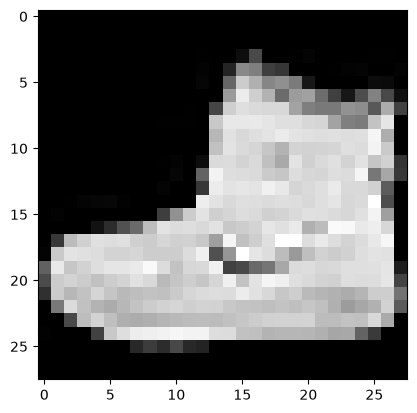

In [8]:
plt.imshow(img.squeeze(), cmap = 'gray')

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
device

'cuda'

In [11]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [12]:
model = myCNN(input_channels = 1, no_of_kernels = 10, output_shape = len(classes))

model

myCNN(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifierblock): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [13]:
model_path = r'C:\Users\offsh\Documents\project\dl\models\cnn_on_mnist_model.pth'

In [14]:
model.load_state_dict(torch.load( f = model_path))

<All keys matched successfully>

In [15]:
val = DataLoader(
    test_data,
    batch_size=1000,
    shuffle=False
)

In [16]:
model = model.to(device)

In [17]:
next(model.parameters()).device

device(type='cuda', index=0)

In [18]:
from torchmetrics import Accuracy

In [19]:
def test_model(model: torch.nn.Module, data: torch.utils.data.DataLoader , accuracy: Accuracy, device: torch.device = device):
    model = model.to(device)
    accuracy = accuracy.to(device)

    accuracy.reset()

    model.eval()

    with torch.inference_mode():
        for X, y in data:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            accuracy.update(y_pred, y)

    acc = accuracy.compute()

    print(f"model accuracy: {acc:.5f}")

In [20]:
accuracy = Accuracy(
    task = 'multiclass',
    num_classes = len(classes)
)

In [21]:
test_model(model = model, data = val, accuracy = accuracy, device = device)

model accuracy: 0.87850


In [22]:
def make_predictions( model: torch.nn.Module, data: torch.utils.data.DataLoader, device: torch.device = device ):

    model = model.to(device)
    model.eval()

    predictions = []

    with torch.inference_mode():

        for X, y in data:

            X = X.to(device)

            y_pred = model(X)

            predictions.append(y_pred.argmax(dim = 1).cpu())

    return torch.cat(predictions)

In [23]:
np.random.seed(42)

ls = np.random.randint(0, len(test_data), size=10)

data = []

for idx in ls:
    image, label = test_data[idx]
    data.append((image, label))

pred_data = DataLoader(
    data,
    batch_size = 10,
    shuffle = False
)

In [25]:
preds = make_predictions(model, pred_data, device)

In [26]:
preds

tensor([0, 6, 8, 8, 2, 1, 3, 8, 2, 5])

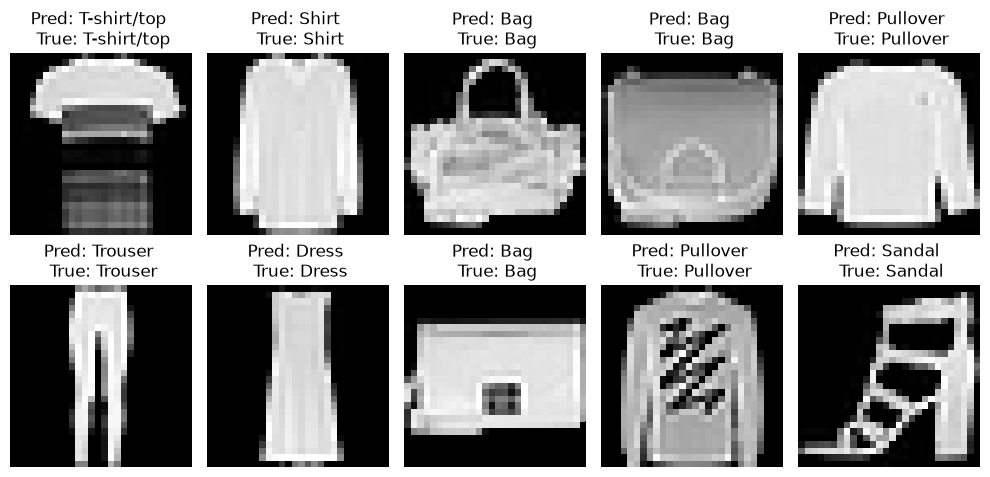

In [32]:
fig = plt.figure(figsize = (10, 5))

for i, (image, true_label) in enumerate(data):

    pred_label = preds[i].item()

    ax = fig.add_subplot(2, 5, i + 1)

    ax.imshow(image.squeeze(), cmap="gray")

    ax.set_title(f"Pred: {classes[pred_label]} \n True: {classes[true_label]}" )

    ax.axis("off")

plt.tight_layout()
plt.show()